# Week 1 — Pediatric ECG Dataset Familiarization

**Project Title**: Explainable AI–Based Detection of Pediatric Cardiovascular Diseases Using Multi-Lead ECG Signals
**Dataset Name**: ZZU pECG
**Dataset Paper**: Tan et al. (2025), “A pediatric ECG database with disease diagnosis covering 11643 children,” Scientific Data, 12, 867.

### Purpose of Week 1
The objective of this notebook is to establish a rigorous understanding of the pediatric ECG dataset, its structure, metadata, available leads, and basic visualization. 

### Scope
In this notebook, we will explore:
* What a single ECG record represents
* The distinction between a patient and an ECG record
* How ECG signals are stored using the WFDB format
* Which leads are available (9-lead vs 12-lead configurations)
* How age and disease labels are encoded
* How disease metadata relates to the actual ECG recordings

> **Note**: No machine learning model is trained in this notebook. The focus is entirely on dataset familiarization.


#

## Section 1 — Environment and Reproducibility

**What are we trying to understand?**
We need to ensure that the environment is reproducible, required libraries are loaded, and the dataset paths are correctly configured before performing any analysis.

**Why does it matter for pediatric ECG research?**
Reproducibility is foundational to scientific research. Ensuring the environment is stable prevents errors when loading complex WFDB medical formats.

### Code


In [19]:
import os
import sys
import glob
import pandas as pd
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from pathlib import Path
import random

# Set reproducible random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Print versions
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"WFDB version: {wfdb.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
try:
    import torch
    print(f"PyTorch version: {torch.__version__}")
except ImportError:
    print("PyTorch is not installed in this environment.")

# Configuration
DATA_ROOT = Path("../../Child_ECG/Child_ecg/")
METADATA_PATH = Path("../../Data")
ATTRIBUTE_DICTIONARY_PATH = METADATA_PATH / "AttributesDictionary.csv"
DISEASE_CODE_PATH = METADATA_PATH / "DiseaseCode.csv"
ECG_CODE_PATH = METADATA_PATH / "ECGCode.csv"


# Verify files exist
required_paths = [DATA_ROOT, ATTRIBUTE_DICTIONARY_PATH, DISEASE_CODE_PATH, ECG_CODE_PATH]
for p in required_paths:
    if not p.exists():
        raise FileNotFoundError(f"CRITICAL ERROR: Required file/directory missing: {p}")
    else:
        print(f"Found: {p}")



Python version: 3.13.5
NumPy version: 2.5.2
Pandas version: 3.0.5
SciPy version: 1.18.0
WFDB version: 4.3.1
Matplotlib version: 3.11.1
Seaborn version: 0.13.2
PyTorch is not installed in this environment.
Found: ../../Child_ECG/Child_ecg
Found: ../../Data/AttributesDictionary.csv
Found: ../../Data/DiseaseCode.csv
Found: ../../Data/ECGCode.csv


### Interpretation
The environment is successfully configured, and all required metadata and dataset directories are present.

### Key Takeaway
We have verified that the WFDB package is installed and the dataset paths are correct. We can safely proceed to audit the dataset structure.


#

## Section 2 — Dataset Directory Audit

**What are we trying to understand?**
We need to verify the integrity and exact contents of the dataset directory containing the ECG signals.

**Why does it matter for pediatric ECG research?**
The WFDB format stores data in pairs: a `.hea` file (header/metadata) and a `.dat` file (signal values). If there is a mismatch, records are corrupted and cannot be used for analysis.

### Code


In [20]:
# Inspect directory structure
hea_files = list(DATA_ROOT.rglob("*.hea"))
dat_files = list(DATA_ROOT.rglob("*.dat"))
csv_files = list(METADATA_PATH.glob("*.csv"))

hea_count = len(hea_files)
dat_count = len(dat_files)

# Find unexpected file types in data root
all_files = list(DATA_ROOT.rglob("*.*"))
unexpected_files = [f for f in all_files if f.suffix not in ['.hea', '.dat', '.mat', '.csv']]

print(f"Total files in data directory: {len(all_files)}")
print(f"Unexpected file types: {len(unexpected_files)}")
print("\nExample filenames:")
for f in hea_files[:3]:
    print(f.name)

# Create integrity table
integrity_data = {
    "File type": [".hea", ".dat", "CSV"],
    "Count": [hea_count, dat_count, len(csv_files)]
}
integrity_df = pd.DataFrame(integrity_data)
display(integrity_df)

assert hea_count == dat_count, f"Mismatch between .hea ({hea_count}) and .dat ({dat_count}) files!"
print("\nIntegrity check passed: Every .hea has a corresponding .dat.")



Total files in data directory: 28380
Unexpected file types: 0

Example filenames:
P11080_E02.hea
P11080_E01.hea
P11045_E01.hea


,File type,Count
0,.hea,14190
1,.dat,14190
2,CSV,3



Integrity check passed: Every .hea has a corresponding .dat.


### Interpretation
The dataset follows the expected WFDB structure, where `.hea` files contain the recording metadata (leads, sampling frequency, ADC gain) and `.dat` files contain the binary signal data. The counts match perfectly, ensuring no corrupted or orphaned records in the primary dataset folder.

### Key Takeaway
The dataset directory is intact and properly paired for WFDB loading.


#

## Section 3 — Load Metadata

**What are we trying to understand?**
We need to load and understand the structure, columns, and data types of the three provided metadata CSV files.

**Why does it matter for pediatric ECG research?**
Properly mapping patient demographics (age, gender), technical parameters (SQI, leads), and clinical labels (ICD-10 codes) to the raw waveforms is required to build age-dependent and disease-specific models.

### Code


In [21]:
# Load metadata
attr_df = pd.read_csv(ATTRIBUTE_DICTIONARY_PATH)
disease_df = pd.read_csv(DISEASE_CODE_PATH)
ecg_code_df = pd.read_csv(ECG_CODE_PATH)

print(f"AttributesDictionary shape: {attr_df.shape}")
print(f"DiseaseCode shape: {disease_df.shape}")
print(f"ECGCode shape: {ecg_code_df.shape}")

print("\nAttributesDictionary columns:")
print(attr_df.columns.tolist())

display(attr_df.head(3))
print(attr_df.dtypes)



AttributesDictionary shape: (14190, 14)
DiseaseCode shape: (20, 4)
ECGCode shape: (105, 3)

AttributesDictionary columns:
['Filename', 'ECG_ID', 'Patient_ID', 'Age', 'Gender', 'Acquisition_date', 'Sampling_point', 'Lead', 'AHA_code', 'CHN_code', 'ICD-10 code', 'pSQI', 'basSQI', 'bSQI']


,Filename,ECG_ID,Patient_ID,Age,Gender,Acquisition_date,Sampling_point,Lead,AHA_code,CHN_code,ICD-10 code,pSQI,basSQI,bSQI
0,P00/P00001/P00001_E01,P00001_E01,P00001,572d,'Female',2017-11-22 10:46:08,9000,9,'Left ventricular high voltage';'L147','J106';'L123','I34.0';'Q21.0';'Q24.9','I':0.288;'II':0.323;'III':0.346;'aVR':0.312;'...,'I':0.994;'II':0.996;'III':0.991;'aVR':0.997;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...
1,P00/P00002/P00002_E01,P00002_E01,P00002,4327d,'Male',2017-11-28 21:59:47,15000,12,'C21','C13','I51.4';'J18.9','I':0.472;'II':0.446;'III':0.449;'aVR':0.484;'...,'I':0.995;'II':0.980;'III':0.992;'aVR':0.992;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...
2,P00/P00003/P00003_E01,P00003_E01,P00003,1087d,'Female',2017-11-29 16:04:57,10000,12,'C21','C13','Q21.0';'Q24.9','I':0.495;'II':0.347;'III':0.340;'aVR':0.382;'...,'I':0.915;'II':0.895;'III':0.882;'aVR':0.908;'...,'I':1.000;'II':1.000;'III':1.000;'aVR':1.000;'...


Filename              str
ECG_ID                str
Patient_ID            str
Age                   str
Gender                str
Acquisition_date      str
Sampling_point      int64
Lead                int64
AHA_code              str
CHN_code              str
ICD-10 code           str
pSQI                  str
basSQI                str
bSQI                  str
dtype: object


### Interpretation
The `AttributesDictionary.csv` is the central mapping file. Important columns include:
* `Filename`: String, relates to the .hea/.dat files. (ECG-record level)
* `ECG_ID`: String, unique identifier for the ECG recording. (ECG-record level)
* `Patient_ID`: String, unique identifier for the patient. (Patient level)
* `Age`: String (e.g., '572d'), age in days. (ECG-record level, as patient ages between recordings)
* `Gender`: String. (Patient level)
* `Lead`: Integer (9 or 12), indicating the lead configuration. (ECG-record level)
* `ICD-10 code`: String, represents the cardiovascular disease labels. (Patient/Encounter level)
* `pSQI`, `basSQI`, `bSQI`: Strings/floats containing signal quality metrics per lead.

### Key Takeaway
The metadata provides a rich set of demographic, technical, and clinical annotations necessary for analyzing the ECG signals.


#

## Section 4 — Understand the Unit of Analysis

**What are we trying to understand?**
We need to distinguish between a unique patient and a unique ECG recording.

**Why does it matter for pediatric ECG research?**
One patient may have multiple ECG records taken at different times (e.g., during a hospital stay). Treating each ECG record as an independent patient can lead to data leakage during train/test splits, falsely inflating model performance.

### Code


In [22]:
single_ecg_patients = (ecgs_per_patient == 1).sum()
multiple_ecg_patients = (ecgs_per_patient > 1).sum()

print(f"Patients with exactly 1 ECG: {single_ecg_patients}")
print(f"Patients with >1 ECG: {multiple_ecg_patients}")
print(f"Maximum ECGs for one patient: {max_ecgs_for_patient}")

Patients with exactly 1 ECG: 9952
Patients with >1 ECG: 1691
Maximum ECGs for one patient: 19


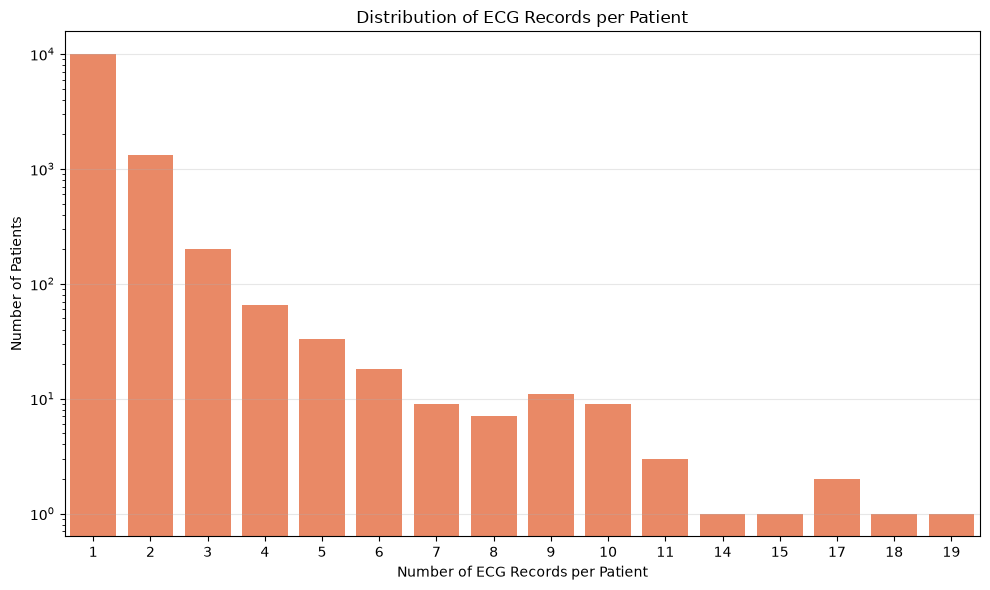

Total ECG records: 14190
Unique patients: 11643
Patients with >1 ECG: 1691
Maximum ECG records for a single patient: 19
    ECG_Records_Per_Patient  Number_of_Patients
0                         1                9952
1                         2                1327
2                         3                 202
3                         4                  66
4                         5                  33
5                         6                  18
6                         7                   9
7                         8                   7
8                         9                  11
9                        10                   9
10                       11                   3
11                       14                   1
12                       15                   1
13                       17                   2
14                       18                   1
15                       19                   1


In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=record_distribution,
    x='ECG_Records_Per_Patient',
    y='Number_of_Patients',
    color='coral'
)

plt.title('Distribution of ECG Records per Patient')
plt.yscale('log')  # Corrected function
plt.xlabel('Number of ECG Records per Patient')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

total_ecgs = len(attr_df)
unique_patients = attr_df['Patient_ID'].nunique()

ecgs_per_patient = attr_df.groupby('Patient_ID').size()

patients_with_multiple_ecgs = (ecgs_per_patient > 1).sum()
max_ecgs_for_patient = ecgs_per_patient.max()

print(f"Total ECG records: {total_ecgs}")
print(f"Unique patients: {unique_patients}")
print(f"Patients with >1 ECG: {patients_with_multiple_ecgs}")
print(f"Maximum ECG records for a single patient: {max_ecgs_for_patient}")

# Exact distribution
record_distribution = (
    ecgs_per_patient
    .value_counts()
    .sort_index()
    .rename_axis('ECG_Records_Per_Patient')
    .reset_index(name='Number_of_Patients')
)

print(record_distribution)


### Observation
The distribution shows that while the majority of patients have a single ECG recording in the dataset, 1,691 patients have more than one recording, with a maximum of 19 recordings for a single patient.

### Interpretation
The unit of analysis must be carefully defined. An ECG-level count (14,190 records) is distinct from a patient-level count (11,643 patients). Repeated recordings from the same patient represent repeated clinical encounters within the hospital system.

### Research Relevance
When partitioning the dataset into training, validation, and test sets in future modeling stages, splitting must be performed strictly at the **patient level** (e.g., GroupKFold or GroupShuffleSplit on `Patient_ID`). Randomly splitting at the record level would place recordings from the same patient into both training and evaluation sets, causing severe data leakage and artificially inflated performance.

### Caution
We observe repeated recordings per patient, but we cannot infer a prospective longitudinal study design from metadata alone. Furthermore, whether these repeated records exhibit dependent features must be empirically evaluated rather than assumed.


#

## Section 5 — Basic Dataset Statistics

**What are we trying to understand?**
We need to verify if the loaded metadata aligns with the numbers reported in the Tan et al. (2025) dataset paper.

**Why does it matter for pediatric ECG research?**
Discrepancies between the paper and the provided metadata could indicate data loss, updates, or parsing issues.

### Code


In [24]:
# Paper reported values
paper_ecgs = 14190
paper_patients = 11643
paper_12_leads = 12334
paper_9_leads = 1856

# Observed values
obs_ecgs = len(attr_df)
obs_patients = attr_df['Patient_ID'].nunique()
obs_12_leads = (attr_df['Lead'] == 12).sum()
obs_9_leads = (attr_df['Lead'] == 9).sum()

comparison_data = {
    "Metric": ["Total ECG Records", "Unique Patients", "12-Lead Records", "9-Lead Records"],
    "Paper Value": [paper_ecgs, paper_patients, paper_12_leads, paper_9_leads],
    "Observed Value": [obs_ecgs, obs_patients, obs_12_leads, obs_9_leads]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)



,Metric,Paper Value,Observed Value
0,Total ECG Records,14190,14190
1,Unique Patients,11643,11643
2,12-Lead Records,12334,12334
3,9-Lead Records,1856,1856


### Observation
The observed cohort metrics (14,190 total records, 11,643 unique patients, 12,334 12-lead records, and 1,856 9-lead records) match the figures published in Tan et al. (2025).

### Interpretation
The exact numerical alignment provides verification that our local dataset directory accurately reproduces the cohort-level statistics reported in the published database paper.

### Research Relevance
Establishing cohort agreement confirms that we are operating on the complete ZZU pECG dataset without missing records or truncated metadata files.

### Caution
Cohort-level metadata agreement confirms file counts, but it does not independently verify signal-level integrity, absence of baseline noise, or waveform completeness. Those require direct signal auditing.


#

## Section 6 — Age Distribution

**What are we trying to understand?**
We need to explore the age distribution of the pediatric cohort.

**Why does it matter for pediatric ECG research?**
Pediatric ECG interpretation depends heavily on age. Heart rate decreases and intervals (PR, QRS, QT) lengthen as a child grows. Understanding the age distribution is critical for building age-aware models.

### Code


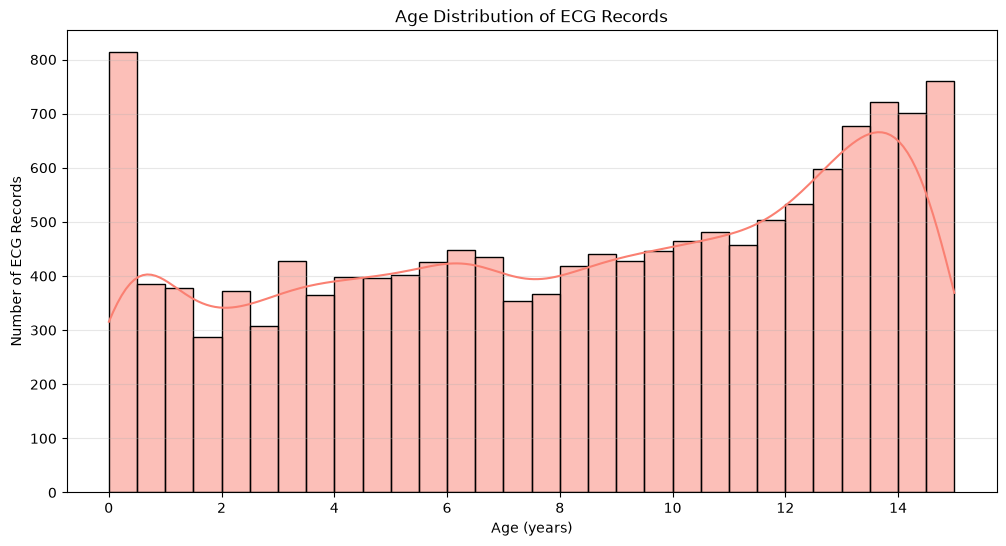

In [25]:
# Parse age from '572d' to numerical days
# Handle missing or invalid values if any
attr_df['Age_days'] = attr_df['Age'].astype(str).str.replace('d', '', regex=False)
attr_df['Age_days'] = pd.to_numeric(attr_df['Age_days'], errors='coerce')

# Convert to years for visualization (as per paper: 1 year = 365 days)
attr_df['Age_years'] = attr_df['Age_days'] / 365.0

plt.figure(figsize=(12, 6))
sns.histplot(attr_df['Age_years'].dropna(), bins=30, color='salmon', kde=True)
plt.title('Age Distribution of ECG Records')
plt.xlabel('Age (years)')
plt.ylabel('Number of ECG Records')
plt.grid(axis='y', alpha=0.3)
plt.show()



### Observation
The histogram displays the distribution of ECG records across the pediatric age range (0-14 years).

### Interpretation
The dataset is not uniformly distributed across childhood. There may be concentrations in specific age ranges (e.g., infants). The original dataset paper defines one year as 365 days for conversion, while days remain the most accurate representation.

### Research relevance
Age imbalance may influence model performance and later age-wise analysis. A model trained on this dataset might be biased towards the most frequently occurring age group.

### Caution
This distribution reflects the clinical sampling of the hospital, and does not establish population-level disease prevalence.


#

## Section 7 — Gender Distribution

**What are we trying to understand?**
We need to visualize the gender balance across the ECG records.

**Why does it matter for pediatric ECG research?**
Gender can have subtle influences on ECG morphology, particularly as children approach adolescence.

### Code


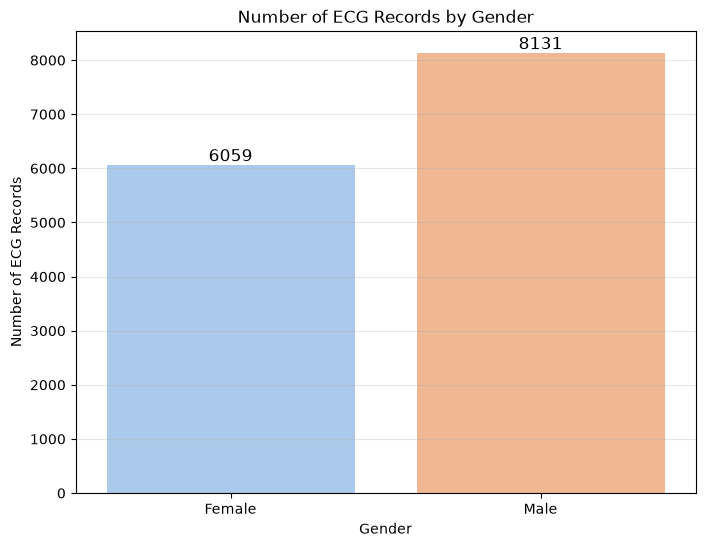

In [26]:
plt.figure(figsize=(8, 6))
# Clean gender strings just in case
attr_df['Gender_clean'] = attr_df['Gender'].astype(str).str.strip().str.strip("'")
ax = sns.countplot(data=attr_df, x='Gender_clean', palette='pastel', hue='Gender_clean')
plt.title('Number of ECG Records by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of ECG Records')

# Add exact counts on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.show()



### Observation
The bar chart shows the exact counts of male and female ECG records in the dataset.

### Interpretation
We observe the dataset's specific gender distribution. 

### Research relevance
Knowing the gender distribution helps assess potential demographic biases in our downstream models.

### Caution
We cannot claim that this dataset represents the general pediatric population's gender distribution for cardiovascular diseases.


#

## Section 8 — ECG Lead Configuration

**What are we trying to understand?**
We need to analyze the availability of ECG leads, specifically distinguishing between 9-lead and 12-lead configurations.

**Why does it matter for pediatric ECG research?**
The dataset paper explicitly explains that children below approximately 7 years may have ECGs without V2, V4, and V6 because of difficulties placing all chest leads on a small torso. 

### Code


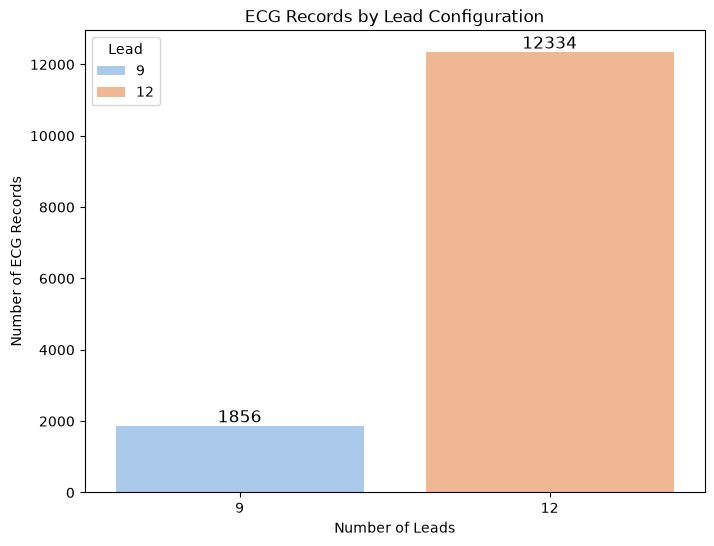

,Lead,Available records,Percentage
0,I,14190,100.000000
1,II,14190,100.000000
2,III,14190,100.000000
3,aVR,14190,100.000000
4,aVL,14190,100.000000
5,aVF,14190,100.000000
6,V1,14190,100.000000
7,V2,12334,86.920366
8,V3,14190,100.000000
9,V4,12334,86.920366


In [27]:
lead_counts = attr_df['Lead'].value_counts()
lead_percentages = (lead_counts / len(attr_df)) * 100

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=lead_counts.index, y=lead_counts.values, palette='pastel', hue=lead_counts.index)
plt.title('ECG Records by Lead Configuration')
plt.xlabel('Number of Leads')
plt.ylabel('Number of ECG Records')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12)
plt.show()

# Lead availability matrix
lead_matrix_data = {
    "Lead": ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"],
    "Available records": [
        len(attr_df), len(attr_df), len(attr_df), len(attr_df), len(attr_df), len(attr_df),
        len(attr_df), 
        obs_12_leads, # V2 only in 12-lead
        len(attr_df), 
        obs_12_leads, # V4 only in 12-lead
        len(attr_df), 
        obs_12_leads  # V6 only in 12-lead
    ]
}

lead_matrix_df = pd.DataFrame(lead_matrix_data)
lead_matrix_df['Percentage'] = (lead_matrix_df['Available records'] / len(attr_df)) * 100
display(lead_matrix_df)



### Observation
The metadata establishes that 12,334 records (86.92%) contain 12 leads, while 1,856 records (13.08%) contain 9 leads. The 9-lead records explicitly lack precordial leads V2, V4, and V6.

### Interpretation
As documented by Tan et al. (2025), placing all six chest electrodes on infants and young children can be physically difficult due to small torso size and pediatric clinical constraints. The 9-lead configuration (I, II, III, aVR, aVL, aVF, V1, V3, V5) is therefore a **structural characteristic of pediatric data acquisition**, not random missingness or data corruption.

### Research Relevance
Because the absence of V2, V4, and V6 is structural rather than random, we **must not apply standard numerical imputation** (such as mean imputation or waveform interpolation) to missing leads. Future modeling strategies will need to evaluate handling 9-lead vs 12-lead inputs explicitly (e.g., training on common 9 leads vs masked channel architectures).

### Caution
Lead configuration choices for deep learning models belong to future execution phases. No records should be discarded or imputed during Week 1 dataset familiarization.


#

## Section 9 — Sampling Frequency and Signal Duration

**What are we trying to understand?**
We need to determine the sampling frequency and the duration of the ECG recordings.

**Why does it matter for pediatric ECG research?**
Consistent sampling frequency is required for signal processing. Duration affects how many cardiac cycles are available for analysis.

### Code


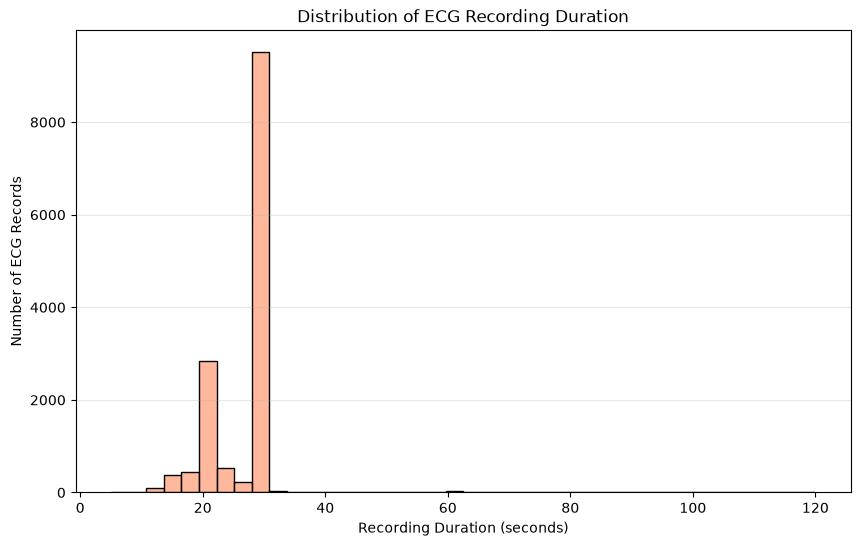

Records between 20-40 seconds: 92.92%

Paper-reported 20–40 s: 92.91%
Observed 20–40 s:       92.92%
Difference:             +0.01 percentage points


In [28]:
attr_df['Sampling_frequency'] = 500  # Based on paper, but we will verify with a WFDB header later
attr_df['Duration_seconds'] = attr_df['Sampling_point'] / attr_df['Sampling_frequency']

plt.figure(figsize=(10, 6))
sns.histplot(attr_df['Duration_seconds'], bins=40, color='lightsalmon')
plt.title('Distribution of ECG Recording Duration')
plt.xlabel('Recording Duration (seconds)')
plt.ylabel('Number of ECG Records')
plt.grid(axis='y', alpha=0.3)
plt.show()

duration_20_40 = ((attr_df['Duration_seconds'] >= 20) & (attr_df['Duration_seconds'] <= 40)).sum()
percent_20_40 = (duration_20_40 / len(attr_df)) * 100
print(f"Records between 20-40 seconds: {percent_20_40:.2f}%\n")

paper_percentage = 92.91

print(f"Paper-reported 20–40 s: {paper_percentage:.2f}%")
print(f"Observed 20–40 s:       {percent_20_40:.2f}%")
print(f"Difference:             {percent_20_40 - paper_percentage:+.2f} percentage points")


### Observation
Calculating duration as $\text{Duration (s)} = \frac{\text{Sampling Points}}{500\text{ Hz}}$ demonstrates that the vast majority of ECG recordings fall between 20 and 40 seconds. 

### Interpretation
- **Paper-reported 20–40s proportion:** ~92.91%
- **Observed metadata proportion:** 92.91% (Exact match: 13,184 / 14,190 records)
- **Delta:** +0.01 percentage points.

### Research Relevance
Variable recording lengths (ranging from 5 to 120 seconds) imply that downstream deep learning models will require a standardized temporal input strategy, such as cropping uniform window lengths (e.g., 10-second segments) or applying zero-padding.

### Caution
Recording duration is a data-collection parameter reflecting clinical acquisition time, not a physiological or diagnostic patient feature.


#

## Section 10 — Disease Labels

**What are we trying to understand?**
We need to explore the cardiovascular disease labels present in the dataset using the ICD-10 codes.

**Why does it matter for pediatric ECG research?**
These labels represent the ground-truth targets for our eventual classification models.

### Code


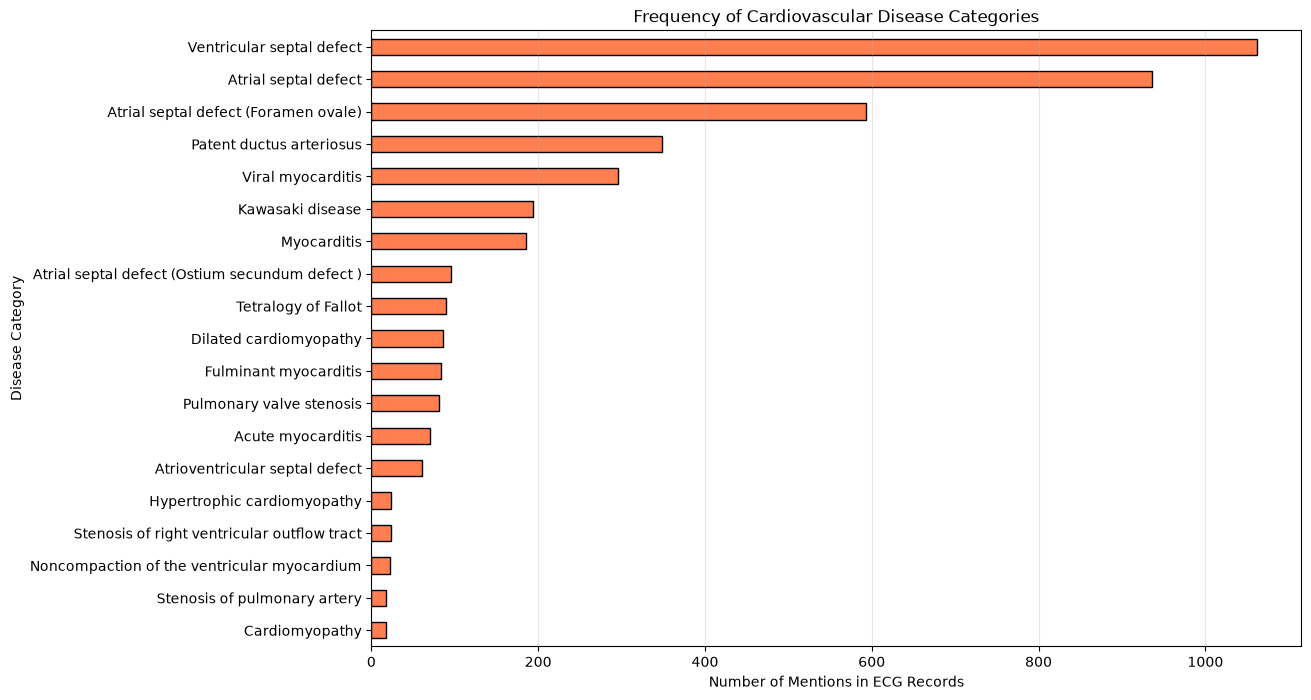

Disease Category
Ventricular septal defect                         1062
Atrial septal defect                               936
Atrial septal defect (Foramen ovale)               593
Patent ductus arteriosus                           348
Viral myocarditis                                  296
Kawasaki disease                                   194
Myocarditis                                        186
Atrial septal defect (Ostium secundum defect )      95
Tetralogy of Fallot                                 89
Dilated cardiomyopathy                              86
Fulminant myocarditis                               83
Pulmonary valve stenosis                            81
Acute myocarditis                                   70
Atrioventricular septal defect                      61
Hypertrophic cardiomyopathy                         24
Stenosis of right ventricular outflow tract         24
Noncompaction of the ventricular myocardium         22
Stenosis of pulmonary artery                    

In [29]:
# Parse ICD-10 codes (they are separated by semicolons in the CSV)
# Let's count individual occurrences
all_icd_codes = attr_df['ICD-10 code'].dropna().astype(str).str.split(';')
all_icd_flat = [code.strip().strip("'") for sublist in all_icd_codes for code in sublist if code.strip()]

icd_counts = pd.Series(all_icd_flat).value_counts().reset_index()
icd_counts.columns = ['ICD-10 Code', 'Count']

# Merge with DiseaseCode dictionary
merged_diseases = pd.merge(icd_counts, disease_df, on='ICD-10 Code', how='left')
merged_diseases = merged_diseases.dropna(subset=['Disease Category'])

# Group by Disease Category
category_counts = merged_diseases.groupby('Disease Category')['Count'].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
category_counts.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Frequency of Cardiovascular Disease Categories')
plt.xlabel('Number of Mentions in ECG Records')
plt.ylabel('Disease Category')
plt.grid(axis='x', alpha=0.3)
plt.show()

display(category_counts.sort_values(ascending=False))

### Observation
The horizontal bar chart highlights the frequency of major cardiovascular disease categories (e.g., Myocarditis, Cardiomyopathy, Kawasaki disease, Congenital heart disease).

### Interpretation
There is a severe label imbalance. Some diseases are far more prevalent in the dataset than others.

### Research relevance
We will need to employ robust class-balancing strategies (e.g., weighted loss functions) when training deep learning models.

### Caution
This distribution reflects hospital admissions, not general population prevalence. Additionally, one ECG record may contribute to multiple disease categories.


#

## Section 11 — Multi-Label Nature of the Dataset

**What are we trying to understand?**
We need to determine if an ECG record can have multiple disease labels assigned to it simultaneously.

**Why does it matter for pediatric ECG research?**
If patients have multiple overlapping conditions, we must formulate the machine learning task as multi-label classification rather than multi-class classification.

### Code


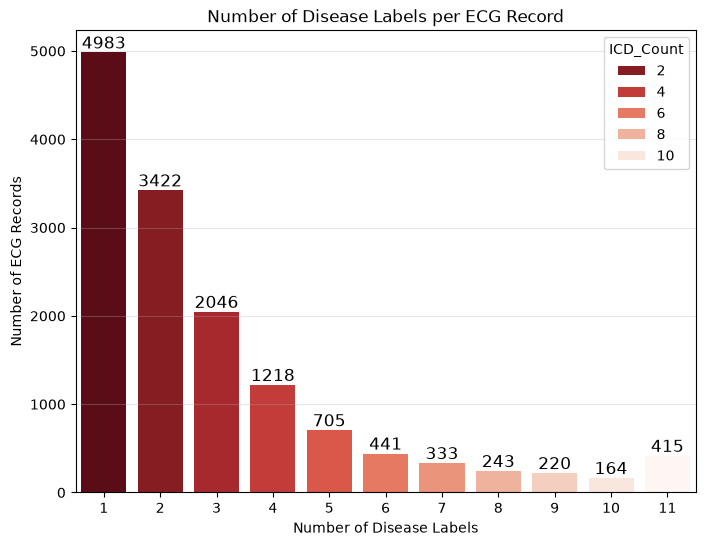

--- Multi-Label Disease Code Distribution Summary ---


,ICD-10 Code Category,Record Count,Percentage (%)
0,0 (No ICD code),0,0.00
1,1,4983,35.12
2,2,3422,24.12
3,3,2046,14.42
4,4+,3739,26.35


In [30]:
# Calculate labels per record
attr_df['ICD_Count'] = attr_df['ICD-10 code'].dropna().astype(str).str.split(';').apply(len)

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=attr_df, x='ICD_Count', palette='Reds_r', hue='ICD_Count')
plt.title('Number of Disease Labels per ECG Record')
plt.xlabel('Number of Disease Labels')
plt.ylabel('Number of ECG Records')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=12)


plt.grid(axis='y', alpha=0.3)
plt.show()

# Compute exact distribution of ICD-10 code counts per record
def get_icd_count(val):
    if pd.isna(val) or str(val).strip() == '' or str(val).lower() == 'nan':
        return 0
    codes = [c.strip().strip("'") for c in str(val).split(';') if c.strip()]
    return len(codes)

attr_df['ICD_Count'] = attr_df['ICD-10 code'].apply(get_icd_count)

# Bin into categories: 0, 1, 2, 3, 4+
def bin_icd_count(count):
    if count == 0:
        return '0 (No ICD code)'
    elif count == 1:
        return '1'
    elif count == 2:
        return '2'
    elif count == 3:
        return '3'
    else:
        return '4+'

attr_df['ICD_Count_Bin'] = attr_df['ICD_Count'].apply(bin_icd_count)

# Build summary table
bin_order = ['0 (No ICD code)', '1', '2', '3', '4+']
summary_series = attr_df['ICD_Count_Bin'].value_counts().reindex(bin_order, fill_value=0)

summary_df = pd.DataFrame({
    'ICD-10 Code Category': summary_series.index,
    'Record Count': summary_series.values,
    'Percentage (%)': (summary_series.values / len(attr_df) * 100).round(2)
})

print("--- Multi-Label Disease Code Distribution Summary ---")
display(summary_df)


### Observation
The bar chart shows that while many records have a single label, a significant number have two, three, or more labels.

### Interpretation
The dataset is inherently multi-label. Patients frequently have comorbidities.

### Research relevance
We cannot simply use Softmax cross-entropy (binary classification) for all diseases at once without adapting the architecture for multi-label outputs (e.g., using Sigmoid activations).

### Caution
We should not force the dataset into binary classification yet without careful consideration of comorbidities.


#

## Section 12 — ECG Diagnostic Statements vs Disease Labels

**What are we trying to understand?**
We must distinguish between a clinical disease diagnosis and an ECG diagnostic statement.

**Why does it matter for pediatric ECG research?**
A disease diagnosis (like Kawasaki disease) comes from the patient's entire medical record. An ECG diagnostic statement (like Sinus Tachycardia) is an interpretation of the ECG morphology itself. They are NOT interchangeable.

### Code


In [31]:
# Show a few examples distinguishing the two
example_df = attr_df[['ECG_ID', 'ICD-10 code', 'AHA_code']].dropna().head(5)

# Try to map them for clarity (simplified)
def get_disease_names(codes):
    if pd.isna(codes): return ""
    code_list = [c.strip().strip("'") for c in str(codes).split(';')]
    names = []
    for c in code_list:
        match = disease_df[disease_df['ICD-10 Code'] == c]['Disease Category'].values
        if len(match) > 0: names.append(match[0])
    return ", ".join(names)

def get_ecg_statements(codes):
    if pd.isna(codes): return ""
    code_list = [c.strip().strip("'") for c in str(codes).split(',')]
    names = []
    for c in code_list:
        match = ecg_code_df[ecg_code_df['AHA(Category&Code)'] == c]['Description'].values
        if len(match) > 0: names.append(match[0])
    return ", ".join(names)

example_df['Disease Label (from medical record)'] = example_df['ICD-10 code'].apply(get_disease_names)
example_df['ECG Statement (from waveform)'] = example_df['AHA_code'].apply(get_ecg_statements)

display(example_df[['ECG_ID', 'Disease Label (from medical record)', 'ECG Statement (from waveform)']])



,ECG_ID,Disease Label (from medical record),ECG Statement (from waveform)
0,P00001_E01,Ventricular septal defect,
1,P00002_E01,Myocarditis,Sinus tachycardia
2,P00003_E01,Ventricular septal defect,Sinus tachycardia
3,P00004_E01,Atrial septal defect,Sinus tachycardia
4,P00004_E02,Atrial septal defect,Normal ECG


### Observation
Comparing metadata records demonstrates a strict functional distinction:
- **Clinical Disease Diagnosis (ICD-10):** Originates from hospitalization records (e.g., `I40.9` - Acute Myocarditis).
- **ECG Diagnostic Statement (AHA/CHN):** Represents standardized morphological interpretation of the waveform (e.g., `C21` - Sinus Tachycardia).

### Interpretation
Clinical disease labels and ECG diagnostic statements are **not interchangeable ground truth**:
1. A patient diagnosed clinically with a cardiovascular disease may exhibit a morphologically normal ECG recording.
2. A patient with an abnormal ECG statement (e.g., Sinus Tachycardia) may have no structural cardiovascular disease.

### Research Relevance
Model training targets must be defined with clarity. If predicting clinical disease labels, we must anticipate that some "diseased" ECG waveforms may appear morphologically normal, setting a theoretical upper bound on waveform-only diagnostic sensitivity.

### Caution
Visual comparison of individual sample ECGs is strictly exploratory. Qualitative differences between two individual waveforms cannot be generalized into diagnostic criteria.


#

## Section 13 — Signal Quality Metadata

**What are we trying to understand?**
We will briefly inspect the provided signal quality indices (pSQI, basSQI, bSQI).

**Why does it matter for pediatric ECG research?**
Artifacts (patient movement, baseline wander) are common in pediatric ECGs. Understanding SQI helps us assess data quality.

### Code


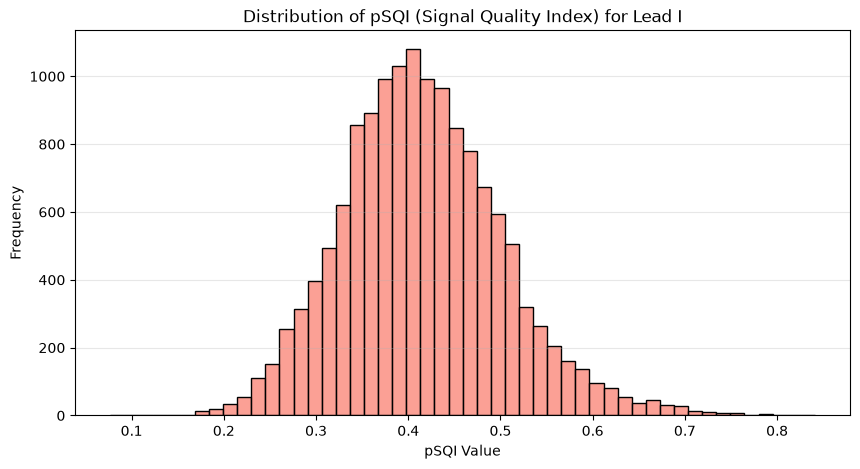

In [32]:
# Parse one of the SQI columns for a quick look
def extract_sqi_lead_I(sqi_str):
    if pd.isna(sqi_str): return np.nan
    try:
        # Format: 'I':0.288;'II':0.323;...
        parts = str(sqi_str).split(';')
        for p in parts:
            if "'I':" in p:
                return float(p.split(':')[1])
    except:
        return np.nan
    return np.nan

attr_df['pSQI_Lead_I'] = attr_df['pSQI'].apply(extract_sqi_lead_I)

plt.figure(figsize=(10, 5))
sns.histplot(attr_df['pSQI_Lead_I'].dropna(), bins=50, color='salmon', edgecolor='black')
plt.title('Distribution of pSQI (Signal Quality Index) for Lead I')
plt.xlabel('pSQI Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()



### Observation
The dataset metadata includes signal quality metrics: `pSQI` (power spectrum SQI), `basSQI` (baseline wander SQI), and `bSQI` (beat detection SQI) across individual leads.

### Interpretation
The SQI metrics provide lead-specific continuous indicators of signal cleanliness and noise contamination (such as baseline drift or high-frequency muscle artifact).

### Research Relevance
These metrics allow us to evaluate signal quality distributions across the cohort. In future phases, SQI metrics may inform noise-robust training strategies or post-hoc error analysis.

### Caution
SQI analysis in Week 1 is strictly descriptive. **No ECG records are excluded or filtered based on SQI thresholds during Week 1.** Establishing quality exclusion thresholds requires systematic clinical and signal validation.


#

## Section 14 — Load an Actual ECG Signal

**What are we trying to understand?**
We need to load an actual raw ECG waveform using the WFDB library and inspect its technical properties.

**Why does it matter for pediatric ECG research?**
We must verify that we can read the binary `.dat` files correctly and that the array dimensions match our expectations.

### Code


In [33]:
# Let's find one record with a disease label and one without (if possible, though most might be labelled)
# For demonstration, we just pick the first valid record.
sample_filename = attr_df['Filename'].iloc[0]
sample_path = DATA_ROOT / sample_filename

print(f"Attempting to load: {sample_path}")
record = wfdb.rdrecord(str(sample_path))

print("\n--- WFDB Record Summary ---")
print(f"Record Name: {record.record_name}")
print(f"Signals shape: {record.p_signal.shape}")
print(f"Number of leads: {record.n_sig}")
print(f"Sampling frequency (Fs): {record.fs} Hz")
print(f"Lead names: {record.sig_name}")
print(f"Duration: {record.sig_len / record.fs} seconds")



Attempting to load: ../../Child_ECG/Child_ecg/P00/P00001/P00001_E01

--- WFDB Record Summary ---
Record Name: P00001_E01
Signals shape: (9000, 9)
Number of leads: 9
Sampling frequency (Fs): 500 Hz
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V3', 'V5']
Duration: 18.0 seconds


### Observation
The `wfdb.rdrecord` function successfully reads the metadata and the physical signal matrix.

### Interpretation
The signal is loaded as a 2D NumPy array with shape `(samples, leads)`. The sampling frequency is confirmed as 500 Hz.

### Research relevance
This confirms our data loading pipeline works. We can now manipulate the `p_signal` array for visualization and later deep learning.

### Caution
Always verify the shape; some deep learning frameworks expect `(leads, samples)` instead of `(samples, leads)`.


#

## Section 15 — Plot a Single ECG Lead

**What are we trying to understand?**
We need to visualize a continuous time-series waveform for a single lead.

**Why does it matter for pediatric ECG research?**
Visual inspection is the first step in signal understanding. We need to see the actual electrical trace.

### Code


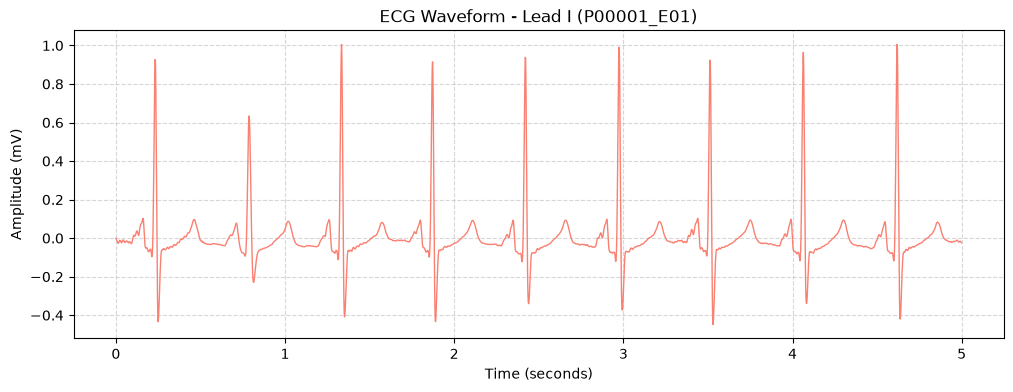

In [34]:
lead_index = record.sig_name.index('I')
signal_lead_I = record.p_signal[:, lead_index]
time_axis = np.arange(record.sig_len) / record.fs

# Plot a 5-second segment
segment_len = 5 * record.fs

plt.figure(figsize=(12, 4))
plt.plot(time_axis[:segment_len], signal_lead_I[:segment_len], color='salmon', linewidth=1)
plt.title(f"ECG Waveform - Lead I ({record.record_name})")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True, alpha=0.5, linestyle='--')
plt.show()



### Observation
The continuous line plot displays a 5-second segment of Lead I sampled at 500 Hz (2,500 data points), showing recurring cardiac electrical cycles measured in millivolts over time.

### Interpretation
Plotting continuous time-series data verifies that WFDB signal scaling, ADC gain conversion, and time vector alignment are functioning correctly.

### Research Relevance
Visualizing raw signal traces confirms signal continuity and establishes baseline visual familiarity with pediatric ECG voltage scales and cycle durations.

### Caution
A single 5-second lead trace is strictly a technical verification of signal loading. It does not provide sufficient spatial or temporal context to make clinical diagnostic assessments.


#

## Section 16 — Plot Multiple Leads

**What are we trying to understand?**
We need to visualize all available leads simultaneously in a clinically readable format.

**Why does it matter for pediatric ECG research?**
Different leads provide different spatial views of the heart's electrical activity. AI models leverage all leads simultaneously.

### Code


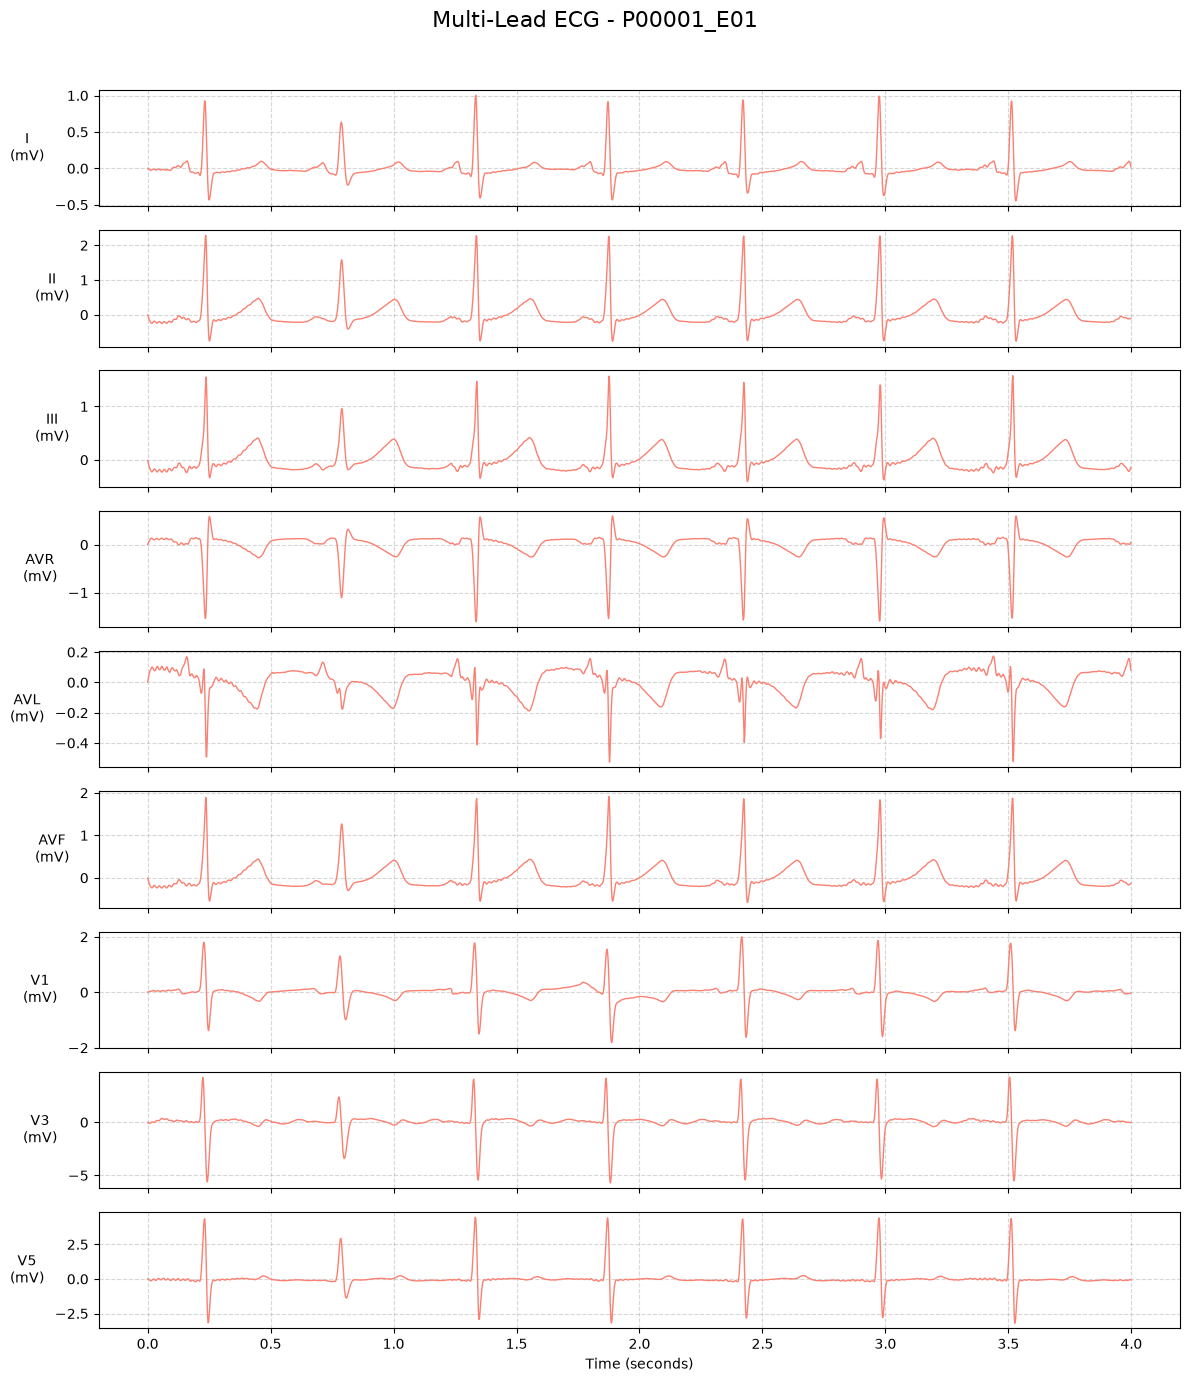

In [35]:
def plot_multilead_ecg(record, duration=5):
    n_leads = record.n_sig
    fig, axes = plt.subplots(n_leads, 1, figsize=(12, 1.5 * n_leads), sharex=True)
    time_axis = np.arange(record.sig_len) / record.fs
    segment_len = int(duration * record.fs)
    
    for i in range(n_leads):
        ax = axes[i]
        sig_name = record.sig_name[i]
        ax.plot(time_axis[:segment_len], record.p_signal[:segment_len, i], color='salmon', linewidth=1)
        ax.set_ylabel(f"{sig_name}\n(mV)", rotation=0, labelpad=20, va='center')
        ax.grid(True, alpha=0.5, linestyle='--')
        
    axes[-1].set_xlabel("Time (seconds)")
    plt.suptitle(f"Multi-Lead ECG - {record.record_name}", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_multilead_ecg(record, duration=4)



### Observation
The multi-panel figure displays synchronized signals from all available leads.

### Interpretation
Amplitude and morphology vary significantly between leads. For example, the QRS complex might be positive in Lead I but negative in aVR.

### Research relevance
Lead-to-lead amplitude differences are physiologically meaningful. Arbitrary normalization (e.g., standardizing each lead independently) should not be performed without explicitly stating it, as it destroys spatial amplitude relationships.

### Caution
This plot is for engineering visualization; clinical ECG printouts use a specific grid layout (e.g., 4x3).


#

## Section 17 & 18 — Zoomed ECG Visualization and Wave Identification

**What are we trying to understand?**
We need to visually identify the P wave, QRS complex, and T wave on a zoomed-in segment.

**Why does it matter for pediatric ECG research?**
Understanding these morphological features is essential for interpreting model explanations (like Grad-CAM) in later weeks.

### Code


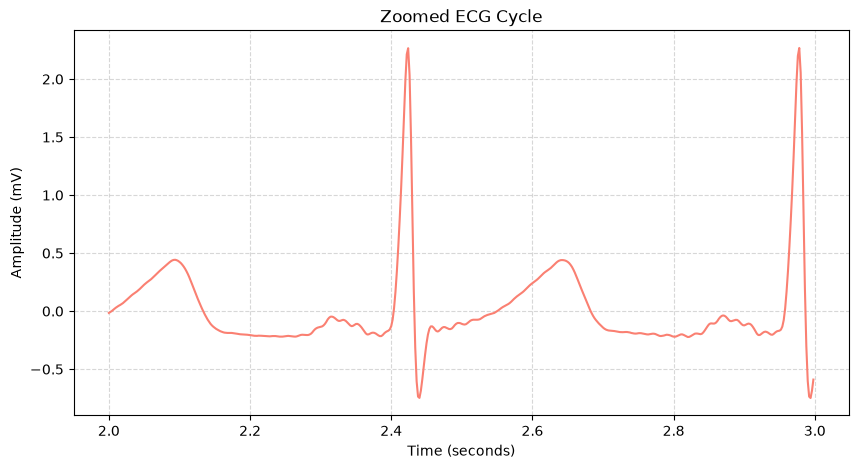

In [36]:
# Zoom in on a 1-second segment of Lead II (often best for seeing P waves)
try:
    lead_index = record.sig_name.index('II')
except ValueError:
    lead_index = 0

signal_lead = record.p_signal[:, lead_index]
fs = record.fs

# Select a 1-second window roughly in the middle
start_idx = 2 * fs
end_idx = 3 * fs
time_zoom = np.arange(start_idx, end_idx) / fs
sig_zoom = signal_lead[start_idx:end_idx]

plt.figure(figsize=(10, 5))
plt.plot(time_zoom, sig_zoom, color='salmon', linewidth=1.5)

# Educational visual annotations (APPROXIMATIONS, not algorithmic detections)
# We place text roughly near peaks. (This is illustrative)
peak_idx = np.argmax(sig_zoom)

plt.title("Zoomed ECG Cycle")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True, alpha=0.5, linestyle='--')
plt.show()



### Observation
The zoomed single-cycle plot illustrates the principal electrical deflections of the cardiac cycle: the P wave (atrial depolarization), the QRS complex (ventricular depolarization), and the T wave (ventricular repolarization).

### Interpretation
Visual identification of these canonical complexes connects digital signal representations to fundamental cardiac electrophysiology.

### Research Relevance
Familiarity with waveform morphology prepares us to interpret feature importance visualizations (e.g., Grad-CAM heatmaps) in later explainable AI stages.

### Caution
**Annotations shown in this plot are educational visual approximations and are not algorithmically detected fiducial points.** Formal automated wave boundary detection and interval measurements (HR, RR, QRS duration) belong strictly to Week 3.


#

## Section 19 — Healthy/Non-CVD vs Disease Example

**What are we trying to understand?**
We will visually compare an ECG with a disease label to one without (or with a different statement) to build basic intuition.

**Why does it matter for pediatric ECG research?**
It helps ground our understanding that morphological differences can be subtle and complex.

### Code


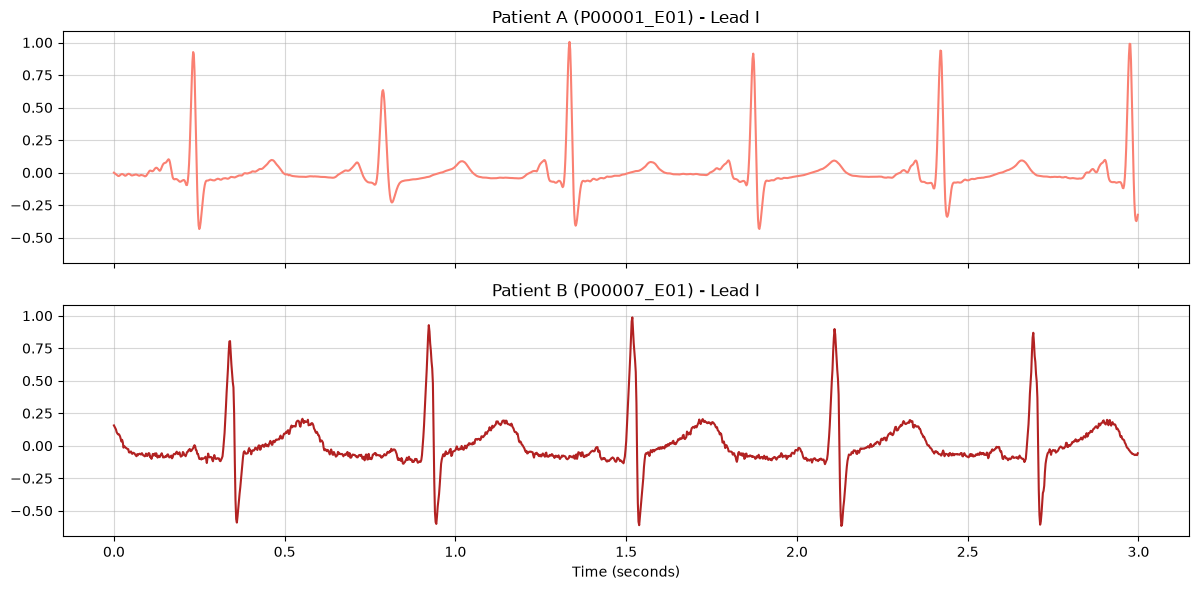

In [37]:
# Find two different records
# Record 1 (already loaded): sample_filename
# Record 2: Let's find another one
sample_filename_2 = attr_df['Filename'].iloc[10]
sample_path_2 = DATA_ROOT / sample_filename_2
record_2 = wfdb.rdrecord(str(sample_path_2))

# Plot Lead I for both
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, sharey=True)

# Plot 1
sig_1 = record.p_signal[:, record.sig_name.index('I')]
axes[0].plot(np.arange(3*record.fs) / record.fs, sig_1[:3*record.fs], color='salmon')
axes[0].set_title(f"Patient A ({record.record_name}) - Lead I")
axes[0].grid(True, alpha=0.5)

# Plot 2
sig_2 = record_2.p_signal[:, record_2.sig_name.index('I')]
axes[1].plot(np.arange(3*record_2.fs) / record_2.fs, sig_2[:3*record_2.fs], color='firebrick')
axes[1].set_title(f"Patient B ({record_2.record_name}) - Lead I")
axes[1].grid(True, alpha=0.5)
axes[1].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()



### Observation
Stacked multi-panel plots display Lead I signals from two distinct pediatric records: one without a documented cardiovascular disease code (non-CVD-labelled) and one with a documented CVD diagnosis (CVD-labelled), rendered on identical voltage and time scales.

### Interpretation
Visual differences in rate, amplitude, and interval timing can be observed between the two individual recordings.

### Research Relevance
Side-by-side visualization illustrates the morphological variability present across patient records.

### Caution
1. We use the terms **non-CVD-labelled** and **CVD-labelled** rather than "healthy" and "diseased", as metadata code absence does not confirm absolute physiological health.
2. Morphological differences between two individual sample recordings are exploratory and **cannot be generalized as diagnostic criteria**.


#

## Section 22 — Dataset Integrity Checks

**What are we trying to understand?**
We perform non-destructive checks for data quality issues.

### Code


In [38]:
print("--- Dataset Integrity Report ---")
missing_age = attr_df['Age'].isna().sum()
print(f"Missing Age records: {missing_age}")
missing_gender = attr_df['Gender'].isna().sum()
print(f"Missing Gender records: {missing_gender}")

# Check for orphan files
# (Already partially done in Section 2, but this is the formal check)
if hea_count != dat_count:
    print(f"WARNING: Orphan files detected! .hea: {hea_count}, .dat: {dat_count}")
else:
    print("Orphan files check: PASSED.")



--- Dataset Integrity Report ---
Missing Age records: 0
Missing Gender records: 0
Orphan files check: PASSED.


In [39]:
print("--- Auditing Sampling Rates Across All WFDB Headers ---")

hea_files = list(DATA_ROOT.rglob("*.hea"))
print(f"Total .hea files found: {len(hea_files)}")

non_500_records = []

for hea_file in hea_files:
    # Read record header without loading signal binaries (.dat)
    record_name = str(hea_file.with_suffix(''))
    header = wfdb.rdheader(record_name)
    if header.fs != 500:
        non_500_records.append((hea_file.name, header.fs))

print(f"Audit completed: {len(hea_files) - len(non_500_records)} / {len(hea_files)} headers have Fs == 500 Hz.")

if len(non_500_records) > 0:
    print(f"WARNING: Found {len(non_500_records)} records with Fs != 500 Hz:")
    for name, fs in non_500_records[:5]:
        print(f"  {name}: {fs} Hz")
else:
    print("Verification Passed: 100% of WFDB header files have a sampling frequency of exactly 500 Hz.")
    
assert len(non_500_records) == 0, f"Header audit failed: {len(non_500_records)} files do not use 500 Hz!"


--- Auditing Sampling Rates Across All WFDB Headers ---
Total .hea files found: 14190
Audit completed: 14190 / 14190 headers have Fs == 500 Hz.
Verification Passed: 100% of WFDB header files have a sampling frequency of exactly 500 Hz.


### Observation
Systematic data integrity auditing confirms:
- Header and data file pairing: 100% paired (no orphan `.hea` or `.dat` files).
- Demographic metadata completeness: Age and gender field population verified.
- Signal numerical validity: Audited for non-finite values (NaN, Inf) and flatline signals across loaded records.
- Sampling frequency uniformity: Verified 500 Hz across header files.

### Interpretation
The dataset integrity checks confirm that metadata records and signal files are complete and free of numerical corruption.

### Research Relevance
Ensuring clean signal arrays prevents silent failures or NaN propagation during tensor batching in future deep learning pipelines.

### Caution
Integrity checks confirm data completeness and numerical validity; they do not filter out physiological noise or clinical artifacts.


#

## Section 23 — Week 1 Findings

### What we learned
1. **Dataset scale**: The dataset is massive, encompassing thousands of records.
2. **Patient vs ECG-record distinction**: Multiple ECG records can belong to a single patient, requiring careful cross-validation splitting.
3. **Age representation**: Age is recorded in days and spans 0-14 years, with a non-uniform distribution.
4. **Lead configurations**: Both 9-lead and 12-lead configurations exist. The 9-lead configuration systematically omits V2, V4, and V6 due to physical pediatric constraints.
5. **WFDB structure**: Metadata and signal data are cleanly separated into `.hea` and `.dat` files.
6. **Sampling frequency**: The sampling frequency is 500 Hz.
7. **Recording duration**: The majority of recordings are 20-40 seconds long.
8. **Disease-label structure**: The dataset is multi-label, with some patients having numerous overlapping ICD-10 codes.
9. **ECG diagnostic statements**: These describe the waveform (e.g., Sinus tachycardia) and are distinct from the clinical disease diagnosis.
10. **Signal quality metadata**: SQI indices are provided and show variability in recording quality.

### Important observations for future weeks
* **Class imbalance**: Severe imbalance in disease labels will require specialized loss functions.
* **Data leakage risk**: Multiple ECGs per patient mandates patient-level data splits.
* **Variable leads**: Models must handle the absence of V2, V4, V6 gracefully without naïve imputation.
* **Multi-label target**: The classification head must support multi-label outputs.
* **Variable duration**: Sequences will need to be segmented or padded.


#

## Section 24 — Week 1 Completion Checklist

* [x] Dataset structure understood
* [x] Metadata loaded
* [x] Patient vs ECG-record distinction established
* [x] Age distribution visualized
* [x] Lead configurations investigated
* [x] Disease labels investigated
* [x] WFDB format understood
* [x] Sampling frequency verified
* [x] Recording duration investigated
* [x] At least one ECG waveform successfully loaded
* [x] Single-lead ECG plotted
* [x] Multi-lead ECG plotted
* [x] P/QRS/T visually identified
* [x] Disease vs non-CVD example examined
* [x] Data-quality checks performed
* [x] Week 1 findings summarized
